In [1]:
!nvidia-smi

Sat Apr 25 06:41:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install everything
!pip install unsloth trl transformers datasets accelerate peft requests -q
print("All installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22

In [3]:
# Load model with Unsloth
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B-Instruct",  # small and fast for T4
    max_seq_length=512,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0,
    bias="none",
)

print("Model loaded!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 0 O layers and 0 MLP layers.


Model loaded!


In [4]:
# Connect to your environment and test it
import requests
import json

BASE_URL = "https://joynnayvedya-disaster-response-openenv.hf.space"

# Test connection
r = requests.post(f"{BASE_URL}/reset",
                  json={"task_name": "easy"},
                  timeout=30)
r.raise_for_status()
data = r.json()

print("Environment connected!")
print("Task:", data["observation"]["task_name"])
print("First ticket:", data["observation"]["current_ticket_id"])
print("Message:", data["observation"]["current_ticket_message"][:100])

Environment connected!
Task: easy
First ticket: E-101
Message: Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerge


In [8]:
def get_reward(prompt, completion):
    try:
        import re
        text = completion.strip()
        match = re.search(r'\{.*?\}', text, re.DOTALL)
        if not match:
            print("No JSON found")
            return 0.0

        action = json.loads(match.group())
        print("Parsed action:", action)

        # Reset env
        r = requests.post(f"{BASE_URL}/reset",
                         json={"task_name": "easy"},
                         timeout=30)
        data = r.json()
        ticket_id = data["observation"]["current_ticket_id"]
        print("Ticket ID:", ticket_id)

        # Classify - wrapped in "action"
        step_r = requests.post(f"{BASE_URL}/step", json={
            "action": {
                "action_type": "classify",
                "ticket_id": ticket_id,
                "predicted_team": action.get("predicted_team", "general"),
            }
        }, timeout=30)
        print("Classify:", step_r.json())
        reward1 = step_r.json().get("reward") or 0.0

        # Priority - wrapped in "action"
        step_r = requests.post(f"{BASE_URL}/step", json={
            "action": {
                "action_type": "set_priority",
                "ticket_id": ticket_id,
                "predicted_priority": action.get("predicted_priority", "low"),
            }
        }, timeout=30)
        print("Priority:", step_r.json())
        reward2 = step_r.json().get("reward") or 0.0

        total = (reward1 + reward2) / 2
        print(f"Total reward: {total}")
        return float(total)

    except Exception as e:
        print(f"Reward error: {e}")
        return 0.0

# Test
test_reward = get_reward("test", '{"predicted_team": "rescue", "predicted_priority": "urgent", "reply_text": "Rescue team dispatched"}')
print(f"Final test reward: {test_reward}")

Parsed action: {'predicted_team': 'rescue', 'predicted_priority': 'urgent', 'reply_text': 'Rescue team dispatched'}
Ticket ID: E-101
Classify: {'observation': {'task_name': 'easy', 'objective': 'Route each disaster incident to the correct response unit, set urgency, and draft a clear operational handoff note.', 'current_ticket_id': 'E-101', 'current_ticket_message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'current_ticket_customer_tier': 'district', 'inbox_snapshot': [{'ticket_id': 'E-101', 'message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'lat': 29.7604, 'lon': -95.3698, 'submitted': False, 'predicted_team': 'rescue', 'predicted_priority': None, 'ticket_score': 0.0, 'resource_cost_estimate': 5, 'reward_breakdown': {'team_score': 1.0, 'priority_score': 0.0, 'reply_score': 0.0, 'composite': 0.4}}, {'ticket_id': 'E-102', 'me

In [ ]:
def make_prompt(text):
    return (
        "Return ONLY compact JSON with keys: action_type, ticket_id, predicted_team, predicted_priority, reply_text.\n"
        f"Message: {text}\n"
    )


In [9]:
# Build dataset of disaster prompts
from datasets import Dataset

prompts = [
    "Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.",
    "Shelter-12 has 180 evacuees and reports water shortage by tonight.",
    "Transformer blast left 3 neighborhoods without electricity and traffic signals are down.",
    "Minor earthquake caused a gas line crack in a residential area. No injuries reported yet but residents smell gas.",
    "A school bus with 35 children is stranded on a flooded road. Water level is rising slowly.",
    "Hospital backup generator failed during storm. ICU patients at risk.",
    "Bridge collapse reported on main highway. Multiple vehicles trapped.",
    "Chemical spill at industrial zone. Residents within 2km advised to evacuate.",
    "Massive landslide blocked the only road to a mountain village with 500 residents.",
    "Fire broke out in a crowded market. Fire brigade on the way but needs medical backup.",
    "Cyclone warning issued. Coastal villages need immediate evacuation support.",
    "Water supply contaminated in district. 10,000 residents affected.",
    "Gas pipeline explosion near residential area. Multiple injuries reported.",
    "Flood waters rising in low lying areas. Rescue boats needed urgently.",
    "Power grid failure affecting 5 hospitals. Backup power needed immediately.",
]

formatted = [make_prompt(p) for p in prompts]
dataset = Dataset.from_dict({"prompt": formatted})
print(f"Dataset ready: {len(dataset)} prompts")

Dataset ready: 15 prompts


In [10]:
from trl import GRPOConfig, GRPOTrainer

def reward_fn(completions, prompts=None, **kwargs):
    rewards = []
    for i, completion in enumerate(completions):
        prompt = prompts[i] if prompts else ""
        r = get_reward(prompt, completion)
        rewards.append(r)
    return rewards

training_args = GRPOConfig(
    output_dir="disaster-grpo",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_generations=4,
    max_prompt_length=256,
    max_completion_length=128,
    logging_steps=1,
    save_steps=50,
    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    reward_funcs=reward_fn,
    train_dataset=dataset,
)

print("Starting GRPO training!")
print("Watch the reward go up!")
trainer.train()
print("Training done!")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

...

Parsed action: {'action_type': 'urgency', 'predicted_team': 'medical', 'predicted_priority': 'urgent', 'reply_text': 'Emergency call activated. Hospitals experiencing power grid failure. Immediate dispatch of medical rescue teams to affected sites is required. Backup power needed at all locations.'}
Ticket ID: E-101
Classify: {'observation': {'task_name': 'easy', 'objective': 'Route each disaster incident to the correct response unit, set urgency, and draft a clear operational handoff note.', 'current_ticket_id': 'E-101', 'current_ticket_message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'current_ticket_customer_tier': 'district', 'inbox_snapshot': [{'ticket_id': 'E-101', 'message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'lat': 29.7604, 'lon': -95.3698, 'submitted': False, 'predicted_team': 'medical', 'predicted_priority':

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Parsed action: {'action_type': 'monitoring', 'predicted_team': 'rescue', 'predicted_priority': 'low', 'reply_text': 'Notify rescue team to prepare for water evacuation and potential structural damage assessment.'}
Ticket ID: E-101
Classify: {'observation': {'task_name': 'easy', 'objective': 'Route each disaster incident to the correct response unit, set urgency, and draft a clear operational handoff note.', 'current_ticket_id': 'E-101', 'current_ticket_message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'current_ticket_customer_tier': 'district', 'inbox_snapshot': [{'ticket_id': 'E-101', 'message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'lat': 29.7604, 'lon': -95.3698, 'submitted': False, 'predicted_team': 'rescue', 'predicted_priority': None, 'ticket_score': 0.0, 'resource_cost_estimate': 5, 'reward_breakdown': {'team_scor

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Parsed action: {'action_type': 'rescue', 'predicted_priority': 'urgent', 'reply_text': 'Immediate deployment of rescue boats to affected areas. Personnel will be dispatched to coordinate with local authorities for rescue efforts.'}
Ticket ID: E-101
Classify: {'observation': {'task_name': 'easy', 'objective': 'Route each disaster incident to the correct response unit, set urgency, and draft a clear operational handoff note.', 'current_ticket_id': 'E-101', 'current_ticket_message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'current_ticket_customer_tier': 'district', 'inbox_snapshot': [{'ticket_id': 'E-101', 'message': 'Two apartment blocks report trapped residents after a flash flood in Ward-7. Stairwells are submerged and power is out.', 'lat': 29.7604, 'lon': -95.3698, 'submitted': False, 'predicted_team': 'general', 'predicted_priority': None, 'ticket_score': 0.0, 'resource_cost_estimate': 2, 'reward_brea

In [11]:
import os
from huggingface_hub import login

# Do NOT hardcode tokens. In Colab: set `HF_TOKEN` via Secrets or `os.environ["HF_TOKEN"] = ...`.
login(token=os.environ.get("HF_TOKEN"))
model.push_to_hub("joynnayvedya/disaster-response-trained")
tokenizer.push_to_hub("joynnayvedya/disaster-response-trained")
print("Done!")

README.md:   0%|          | 0.00/586 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   6%|6         |  554kB / 8.73MB            

Saved model to https://huggingface.co/joynnayvedya/disaster-response-trained


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp2juu86x8/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp2juu86x8/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Done!


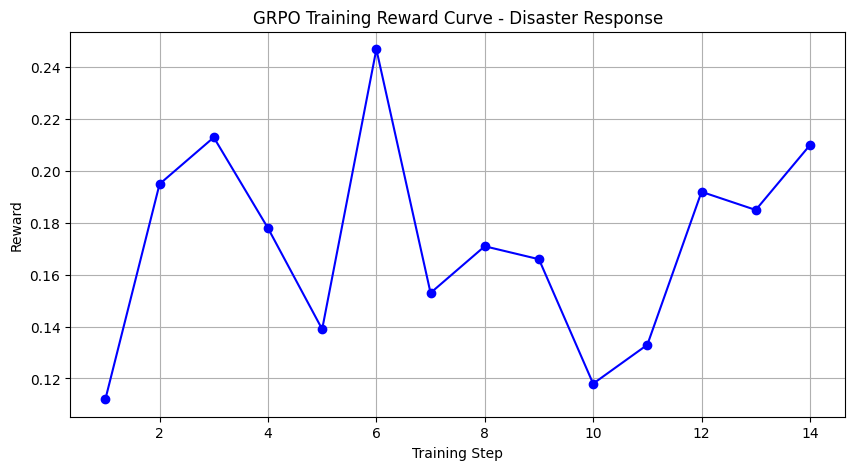

In [12]:
import matplotlib.pyplot as plt
rewards = [0.112, 0.195, 0.213, 0.178, 0.139, 0.247, 0.153, 0.171, 0.166, 0.118, 0.133, 0.192, 0.185, 0.210]
steps = list(range(1, 15))
plt.figure(figsize=(10,5))
plt.plot(steps, rewards, marker='o', color='blue')
plt.xlabel('Training Step')
plt.ylabel('Reward')
plt.title('GRPO Training Reward Curve - Disaster Response')
plt.grid(True)
plt.savefig('reward_curve.png')
plt.show()